# Breast cancer classification with a PyTorch neural network

This notebook loads the prepared CSV splits, trains a small feed-forward neural network, selects the best epoch using validation loss, and evaluates once on the test set.

> Educational example only—not a clinical diagnostic system.

In [1]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {device}")

PyTorch 2.13.0 | device: cpu


## Load the CSV splits

In [2]:
# This works whether Jupyter starts in the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TARGET = "malignant"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

for name, frame in {"train": train_df, "validation": val_df, "test": test_df}.items():
    assert TARGET in frame.columns, f"{name}.csv is missing '{TARGET}'"
    assert not frame.isna().any().any(), f"{name}.csv contains missing values"
    print(f"{name:10s}: {frame.shape[0]:3d} rows, {frame.shape[1] - 1} features, malignant rate={frame[TARGET].mean():.3f}")

train_df.head()

train     : 341 rows, 30 features, malignant rate=0.372
validation: 114 rows, 30 features, malignant rate=0.377
test      : 114 rows, 30 features, malignant rate=0.368


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,0.340045,0.786496,0.459512,0.306419,0.470768,1.554348,1.060678,1.103529,-0.125749,0.683480,...,0.265398,0.484101,0.163679,0.041270,1.290965,0.858567,0.773209,0.274964,0.362750,1.0
1,-1.150783,-0.375912,-1.105077,-0.889455,-0.464667,-0.481052,-0.404553,-0.521235,-0.029940,0.470366,...,-0.386338,-0.929263,-0.689308,-0.019048,-0.388974,-0.581979,-0.738666,0.426918,-0.267187,0.0
2,-0.474273,0.175182,-0.455013,-0.417219,0.521607,-0.358255,-0.508135,-0.488569,0.482036,-0.128625,...,0.041433,-0.476498,-0.384434,0.384127,-0.588106,-0.786743,-0.794387,0.697540,-0.699659,0.0
3,0.042506,-1.452555,0.058162,0.020632,1.726487,0.183901,0.099257,0.648235,1.868263,0.644388,...,-1.446809,-0.143548,-0.118082,0.469841,-0.377744,-0.520716,-0.240773,-0.144718,-0.373476,0.0
4,0.006711,-0.458029,0.000000,0.006113,-1.219624,-0.278055,0.214993,-0.088235,-1.068862,-0.387137,...,-0.297872,-0.129032,-0.076258,-0.882540,0.210311,0.385524,-0.079264,-1.102750,-0.160410,0.0


## Convert data to PyTorch tensors

The processed features are already scaled, so no transformation is fitted here.

In [3]:
feature_names = [column for column in train_df.columns if column != TARGET]
assert feature_names == [c for c in val_df.columns if c != TARGET]
assert feature_names == [c for c in test_df.columns if c != TARGET]

def to_tensors(frame):
    X = torch.tensor(frame[feature_names].to_numpy(dtype=np.float32))
    y = torch.tensor(frame[TARGET].to_numpy(dtype=np.float32)).reshape(-1, 1)
    return X, y

X_train, y_train = to_tensors(train_df)
X_val, y_val = to_tensors(val_df)
X_test, y_test = to_tensors(test_df)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=32, shuffle=True, generator=generator
)
print(X_train.shape, y_train.shape)

torch.Size([341, 30]) torch.Size([341, 1])


## Define and train a small neural network

In [4]:
class BinaryClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)

model = BinaryClassifier(len(feature_names)).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
model

BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [ ]:
def evaluate_loss(model, X, y):
    model.eval()
    with torch.no_grad():
        return loss_fn(model(X.to(device)), y.to(device)).item()

EPOCHS = 10
PATIENCE = 12
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(X_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss = evaluate_loss(model, X_val, y_val)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)

Epoch   1 | train loss 0.6982 | val loss 0.6755
Epoch  10 | train loss 0.1885 | val loss 0.1874
Epoch  20 | train loss 0.0831 | val loss 0.1056
Epoch  30 | train loss 0.0580 | val loss 0.0877
Epoch  40 | train loss 0.0403 | val loss 0.0842
Epoch  50 | train loss 0.0300 | val loss 0.0845
Early stopping at epoch 51


<All keys matched successfully>

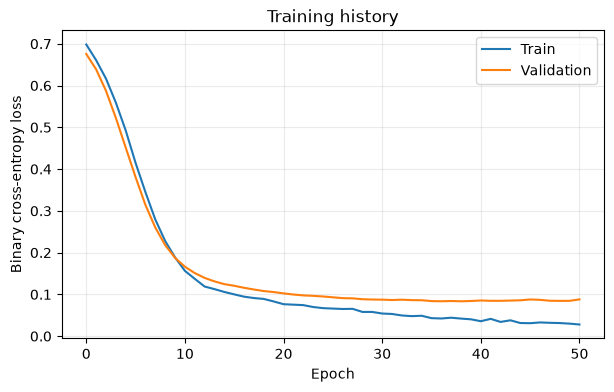

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training history")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Evaluate on the held-out test set

In [7]:
model.eval()
with torch.no_grad():
    probabilities = torch.sigmoid(model(X_test.to(device))).cpu().numpy().ravel()
predictions = (probabilities >= 0.5).astype(int)
actual = y_test.numpy().astype(int).ravel()

tp = int(((predictions == 1) & (actual == 1)).sum())
tn = int(((predictions == 0) & (actual == 0)).sum())
fp = int(((predictions == 1) & (actual == 0)).sum())
fn = int(((predictions == 0) & (actual == 1)).sum())
accuracy = (tp + tn) / len(actual)
precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 score : {f1:.3f}")
print(f"Confusion matrix [[TN, FP], [FN, TP]]: [[{tn}, {fp}], [{fn}, {tp}]]")

Accuracy : 0.982
Precision: 1.000
Recall   : 0.952
F1 score : 0.976
Confusion matrix [[TN, FP], [FN, TP]]: [[72, 0], [2, 40]]


## Save the trained model and test predictions

In [8]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

torch.save(
    {"model_state_dict": model.cpu().state_dict(), "feature_names": feature_names},
    OUTPUT_DIR / "pytorch_classifier.pt",
)
pd.DataFrame(
    {"actual": actual, "probability_malignant": probabilities, "predicted": predictions}
).to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
print(f"Saved artifacts to {OUTPUT_DIR.resolve()}")

Saved artifacts to /Users/mipopovic/Desktop/psi_practical_recap/outputs
